                🚢 Titanic Survival Prediction

                           START
                             │
                             ▼
                    1. Load Dataset
                  (Read the CSV file)
                             │
                             ▼
                  2. Understand Data
        (Rows, Columns, Data Types, Summary)
                             │
                             ▼
                  3. Clean the Data
      (Handle Missing Values & Remove Useless Columns)
                             │
                             ▼
                 4. Preprocess Data
      (Convert Text → Numbers for Machine Learning)
                             │
                             ▼
                 5. Feature Selection
      (Choose Input Features & Target Variable)
                             │
                             ▼
                 6. Split the Dataset
        (80% Training + 20% Testing)
                             │
                             ▼
                 7. Train the Model
           (Decision Tree Classifier)
                             │
                             ▼
                  8. Make Predictions
          (Predict Survived or Not)
                             │
                             ▼
                9. Evaluate Accuracy
          (Check How Well Model Works)
                             │
                             ▼
             10. Visualize Decision Tree
         (See How Model Makes Decisions)
                             │
                             ▼
          11. Overfitting & Tree Pruning
           (Improve Model Performance)
                             │
                             ▼
                      🎉 PROJECT DONE

# 🚢 Titanic Survival Prediction using Decision Tree

## Objective
The goal of this project is to predict whether a passenger survived the Titanic disaster using a Decision Tree Classifier.

### Concepts Learned
- Data Loading
### - Data Exploration
- Data Cleaning
- Preprocessing
- Feature Selection
- Train-Test Split
- Decision Tree
- Prediction
- Accuracy Evaluation
- Decision Tree Visualization
- Overfitting
- Pruning

# 1️⃣ Import Libraries

In this step, we import all the required Python libraries. These libraries help us read the dataset, process the data, build the machine learning model, evaluate its performance, and visualize the Decision Tree.

In [36]:
import pandas as pd

df = pd.read_csv("train.csv")

# 2️⃣ Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame using `pd.read_csv()`. A DataFrame is like an Excel sheet that stores data in rows and columns.

In [35]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (2).csv


# 4️⃣ Check Dataset Size

The `shape` function tells us the number of rows and columns in the dataset.

Rows = Number of passengers

Columns = Number of features

In [37]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4️⃣ Check Dataset Size

The `shape` function tells us the number of rows and columns in the dataset.

Rows = Number of passengers

Columns = Number of features

In [38]:
df.shape

(891, 12)

# 5️⃣ Understand the Dataset

The `info()` function provides information about the dataset, including:
- Column names
- Data types
- Missing values
- Memory usage

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 6️⃣ Statistical Summary

The `describe()` function provides statistical information about numerical columns such as:
- Count
- Mean
- Minimum value
- Maximum value
- Standard deviation

In [40]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 7️⃣ Check Missing Values

Machine learning models cannot work with missing values.

We use `isnull().sum()` to find the number of missing values in each column before cleaning the dataset.

In [41]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# 8️⃣ Data Cleaning

The missing values are handled as follows:

- Age → Filled with Median
- Embarked → Filled with Mode
- Cabin → Removed because it contained too many missing values

This step improves the quality of the dataset before training the model.

In [42]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [43]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [44]:
df.drop("Cabin", axis=1, inplace=True)

In [45]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# 9️⃣ Remove Unnecessary Columns

Some columns such as PassengerId, Name, and Ticket do not help in predicting survival.

These columns are removed to simplify the dataset and improve model performance.

In [46]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [47]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [48]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

# 🔟 Data Preprocessing

Machine learning models understand numbers, not text.

The categorical columns are converted into numerical values:

- Sex → Encoded using map()
- Embarked → Encoded using One-Hot Encoding

In [49]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [50]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [51]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [52]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


# 1️⃣1️⃣ Feature Selection

The dataset is divided into:

- Features (X): Input variables
- Target (y): Output variable (Survived)

The model learns from X to predict y.

In [53]:
X = df.drop("Survived", axis=1)

In [54]:
y = df["Survived"]

In [55]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


In [56]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


# 1️⃣2️⃣ Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to train the model, while the testing data is used to evaluate its performance.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


# 1️⃣3️⃣ Build the Decision Tree Model

A Decision Tree Classifier is created and trained using the training dataset.

The model learns patterns from the training data to predict passenger survival.

In [59]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# 1️⃣4️⃣ Make Predictions

After training, the model predicts whether passengers in the testing dataset survived or not.

In [60]:
y_pred = model.predict(X_test)

In [61]:
print(y_pred[:10])

[0 0 1 1 1 0 1 0 1 1]


# 1️⃣5️⃣ Evaluate the Model

The model's performance is measured using Accuracy.

Accuracy tells us the percentage of correct predictions made by the model.

In [62]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7877094972067039


# 1️⃣6️⃣ Visualize the Decision Tree

The Decision Tree is visualized to understand how the model makes decisions.

Each node represents a question, and the branches represent different decision paths.

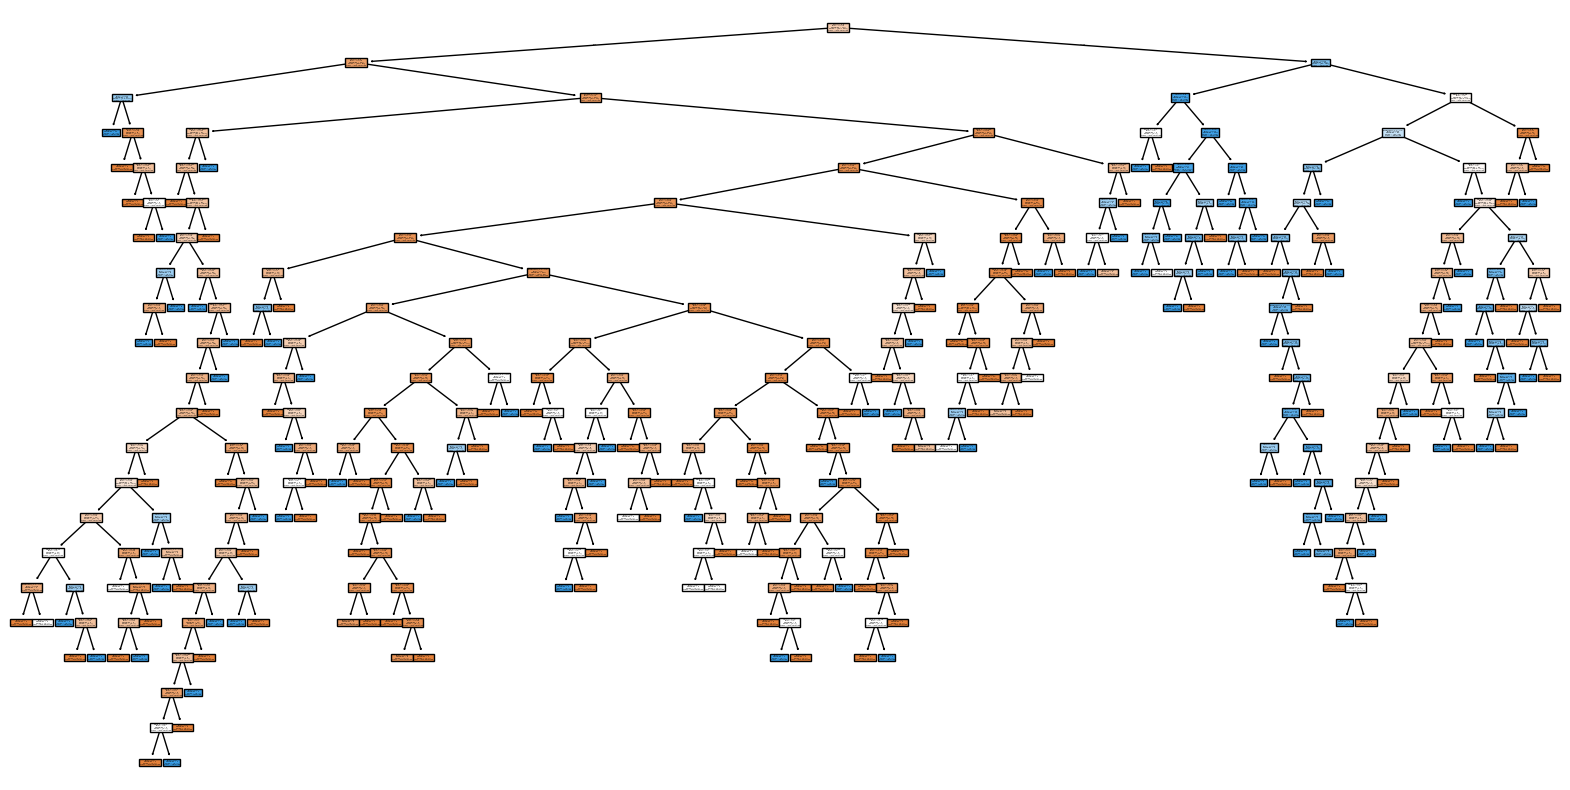

In [63]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)

plt.show()

# 1️⃣7️⃣ Overfitting

The original Decision Tree grew very large and learned the training data too closely.

This is called Overfitting, where the model performs well on training data but may not generalize well to new data.

In [64]:
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Training Accuracy: 0.9789325842696629
Testing Accuracy: 0.7877094972067039


# 1️⃣8️⃣ Pruning the Decision Tree

To reduce overfitting, the tree is pruned by limiting its maximum depth.

A simpler tree is easier to understand and often performs better on unseen data.

In [65]:
from sklearn.tree import DecisionTreeClassifier

pruned_model = DecisionTreeClassifier(max_depth=4, random_state=42)

pruned_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

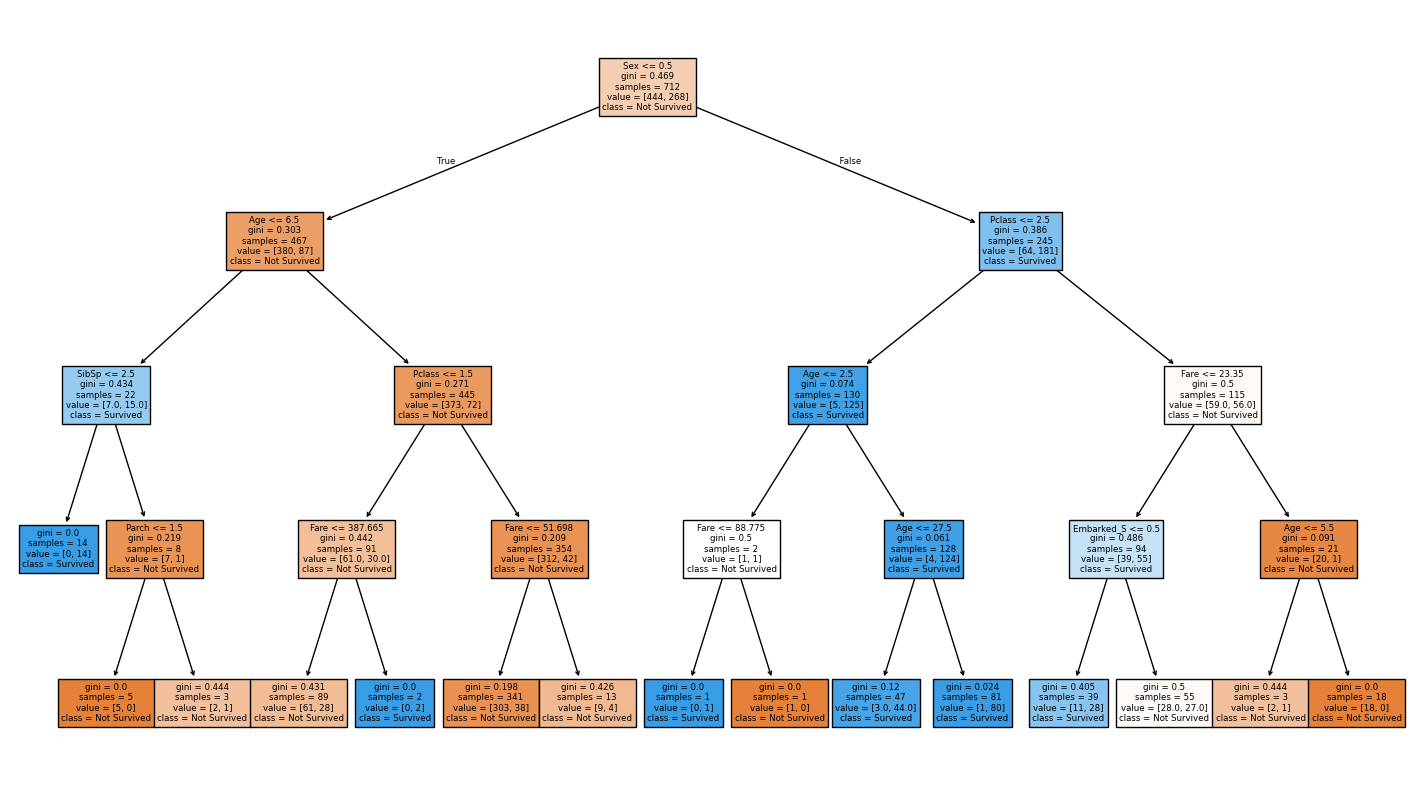

In [66]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    pruned_model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)

plt.show()

In [67]:
y_pred_pruned = pruned_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Pruned Accuracy:", accuracy_score(y_test, y_pred_pruned))

Pruned Accuracy: 0.7988826815642458


# ✅ Conclusion

In this project, a Decision Tree Classifier was used to predict Titanic passenger survival.

The dataset was cleaned, preprocessed, and divided into training and testing sets.

The Decision Tree achieved an accuracy of approximately **78.77%**.

After applying pruning (`max_depth=4`), the model achieved an improved accuracy of approximately **79.89%**.

This project demonstrates the complete workflow of a basic machine learning classification problem using Python and Scikit-learn.